In [10]:
# =========================
# ORGANIZAR DATASET
# =========================

import os
import shutil
from sklearn.model_selection import train_test_split

# Ruta donde están TODAS
# las imágenes mezcladas

source_dir = "../data/raw/dogs-vs-cats/train"

# Carpeta destino procesada

base_dir = "../data/processed"

# Carpetas train

train_cat_dir = os.path.join(base_dir, "train", "cat")
train_dog_dir = os.path.join(base_dir, "train", "dog")

# Carpetas test

test_cat_dir = os.path.join(base_dir, "test", "cat")
test_dog_dir = os.path.join(base_dir, "test", "dog")

# Crear carpetas si no existen

os.makedirs(train_cat_dir, exist_ok=True)
os.makedirs(train_dog_dir, exist_ok=True)

os.makedirs(test_cat_dir, exist_ok=True)
os.makedirs(test_dog_dir, exist_ok=True)

# Obtener todas las imágenes jpg

all_images = [
    img for img in os.listdir(source_dir)
    if img.endswith(".jpg")
]

# Separar imágenes de gatos

cat_images = [
    img for img in all_images
    if img.startswith("cat")
]

# Separar imágenes de perros

dog_images = [
    img for img in all_images
    if img.startswith("dog")
]

# Dividir gatos en train/test

cat_train, cat_test = train_test_split(
    cat_images,
    test_size=0.2,
    random_state=42
)

# Dividir perros en train/test

dog_train, dog_test = train_test_split(
    dog_images,
    test_size=0.2,
    random_state=42
)

# Función para copiar imágenes

def copy_images(image_list, destination_folder):

    for img in image_list:

        source_path = os.path.join(
            source_dir,
            img
        )

        destination_path = os.path.join(
            destination_folder,
            img
        )

        if not os.path.exists(destination_path):

            shutil.copy(
                source_path,
                destination_path
            )

# Copiar imágenes train

copy_images(cat_train, train_cat_dir)
copy_images(dog_train, train_dog_dir)

# Copiar imágenes test

copy_images(cat_test, test_cat_dir)
copy_images(dog_test, test_dog_dir)

print("Dataset organizado correctamente.")

print("Train cats:", len(os.listdir(train_cat_dir)))
print("Train dogs:", len(os.listdir(train_dog_dir)))

print("Test cats:", len(os.listdir(test_cat_dir)))
print("Test dogs:", len(os.listdir(test_dog_dir)))

Dataset organizado correctamente.
Train cats: 10000
Train dogs: 10000
Test cats: 2500
Test dogs: 2500


In [11]:
# Crear carpeta para guardar datos
!mkdir -p ../data/raw

# Descargar el dataset
!wget -O ../data/raw/dogs-vs-cats.zip https://storage.googleapis.com/datascience-materials/dogs-vs-cats.zip

# Descomprimirlo
!unzip -q ../data/raw/dogs-vs-cats.zip -d ../data/raw

--2026-06-24 14:12:01--  https://storage.googleapis.com/datascience-materials/dogs-vs-cats.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.129.207, 142.250.140.207, 192.178.223.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.129.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 581507449 (555M) [application/zip]
Saving to: ‘../data/raw/dogs-vs-cats.zip’

../data/raw/dogs-vs 100%[===================>] 554.57M  51.4MB/s    in 12s     

2026-06-24 14:12:13 (47.4 MB/s) - ‘../data/raw/dogs-vs-cats.zip’ saved [581507449/581507449]

replace ../data/raw/__MACOSX/._dogs-vs-cats? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [12]:
import os

os.listdir("../data/raw")

['dogs-vs-cats.zip', '__MACOSX', 'dogs-vs-cats']

In [13]:
import os

os.listdir("../data/raw/dogs-vs-cats")

['.DS_Store', 'sampleSubmission.csv', 'train']

Número de imágenes de gatos en train: 10000
Número de imágenes de perros en train: 10000


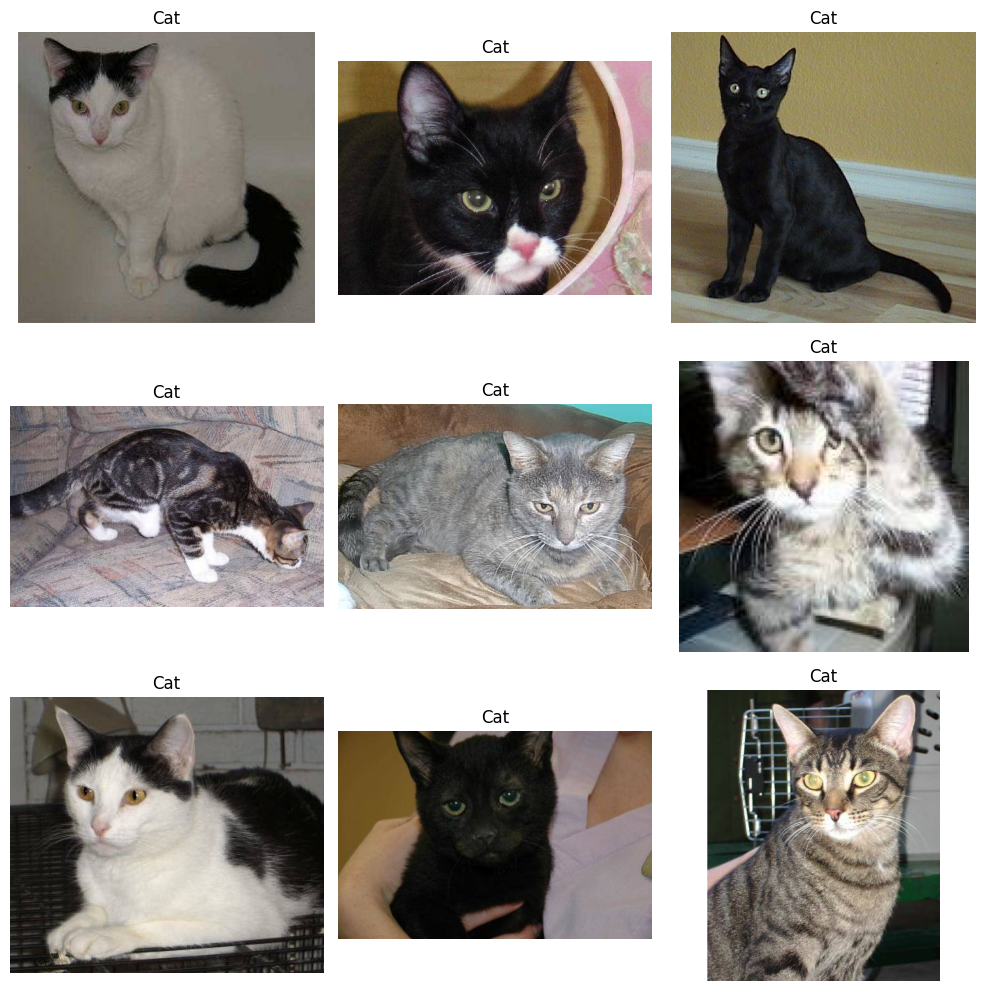

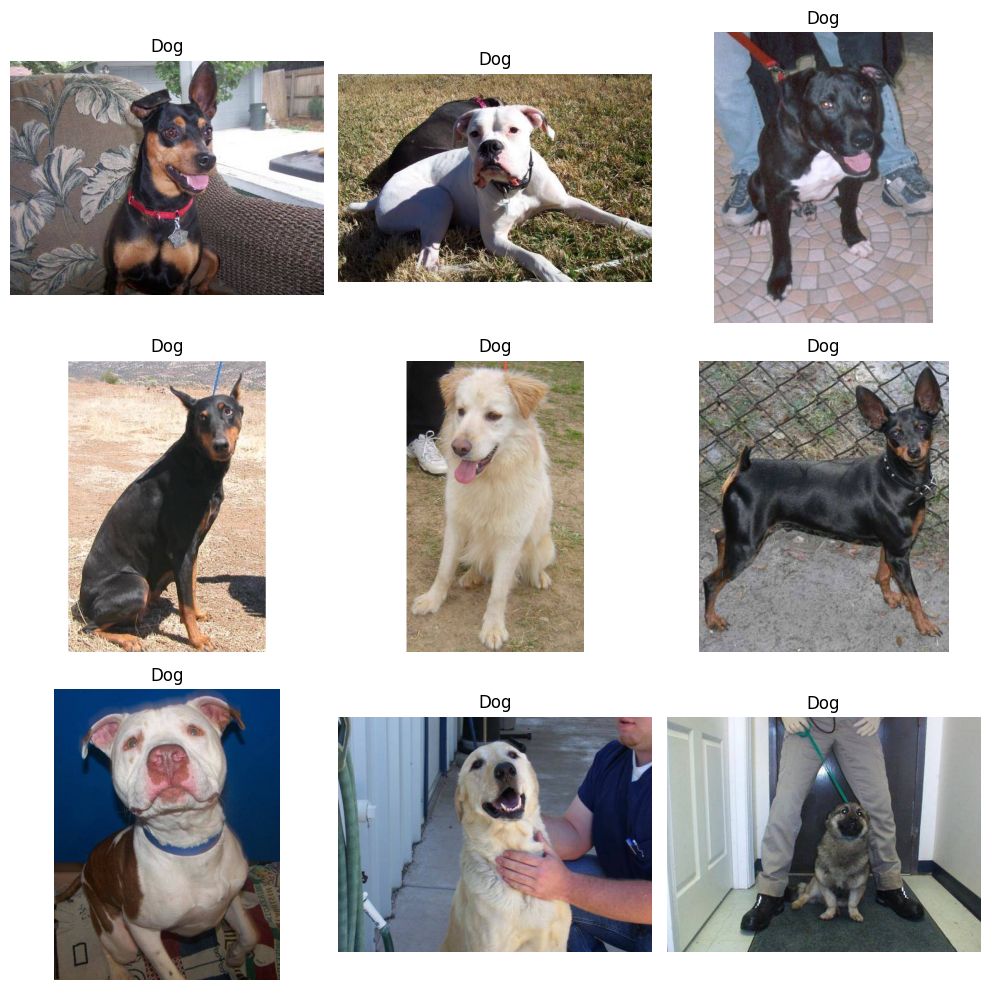

../data/processed/train/cat/cat.1320.jpg -> tamaño: (279, 274)
../data/processed/train/cat/cat.10001.jpg -> tamaño: (500, 374)
../data/processed/train/dog/dog.9390.jpg -> tamaño: (500, 374)
../data/processed/train/dog/dog.783.jpg -> tamaño: (500, 332)


In [14]:
# =========================
# EDA VISUAL DEL DATASET
# =========================

import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Rutas de las carpetas ya organizadas

train_cat_dir = "../data/processed/train/cat"
train_dog_dir = "../data/processed/train/dog"

# Listamos imágenes

cat_images = os.listdir(train_cat_dir)
dog_images = os.listdir(train_dog_dir)

print("Número de imágenes de gatos en train:", len(cat_images))
print("Número de imágenes de perros en train:", len(dog_images))

# =========================
# VISUALIZAR 9 GATOS
# =========================

plt.figure(figsize=(10, 10))

for i in range(9):
    img_path = os.path.join(train_cat_dir, cat_images[i])
    img = image.load_img(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title("Cat")
    plt.axis("off")

plt.tight_layout()
plt.show()

# =========================
# VISUALIZAR 9 PERROS
# =========================

plt.figure(figsize=(10, 10))

for i in range(9):
    img_path = os.path.join(train_dog_dir, dog_images[i])
    img = image.load_img(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title("Dog")
    plt.axis("off")

plt.tight_layout()
plt.show()

# =========================
# COMPROBAR TAMAÑOS DE IMÁGENES
# =========================

sample_paths = [
    os.path.join(train_cat_dir, cat_images[0]),
    os.path.join(train_cat_dir, cat_images[1]),
    os.path.join(train_dog_dir, dog_images[0]),
    os.path.join(train_dog_dir, dog_images[1])
]

for path in sample_paths:
    img = image.load_img(path)
    print(path, "-> tamaño:", img.size)

 Interpretación del EDA

El dataset está formado por imágenes de perros y gatos.

Tras organizar los archivos, se observa que las clases están balanceadas:
hay el mismo número de imágenes de perros y gatos tanto en entrenamiento como en prueba.

Las imágenes son a color y presentan distintos tamaños, encuadres y posiciones de los animales.
Por este motivo, antes de entrenar la red neuronal será necesario redimensionarlas a un tamaño fijo.

En este proyecto se utilizará un tamaño común de 224x224 píxeles para que todas las imágenes tengan la misma entrada en la CNN.

In [16]:
# =========================
# IMPORTACIÓN DE LIBRERÍAS
# =========================

# os:
# permite trabajar con carpetas
# y rutas de archivos

import os

# numpy:
# utilizado para trabajar
# con arrays numéricos

import numpy as np

# matplotlib:
# utilizado para visualizar imágenes
# y gráficos

import matplotlib.pyplot as plt

# tensorflow.keras:
# framework utilizado
# para construir y entrenar
# redes neuronales convolucionales

from tensorflow import keras

# image:
# utilidades para cargar
# y procesar imágenes

from keras.preprocessing import image



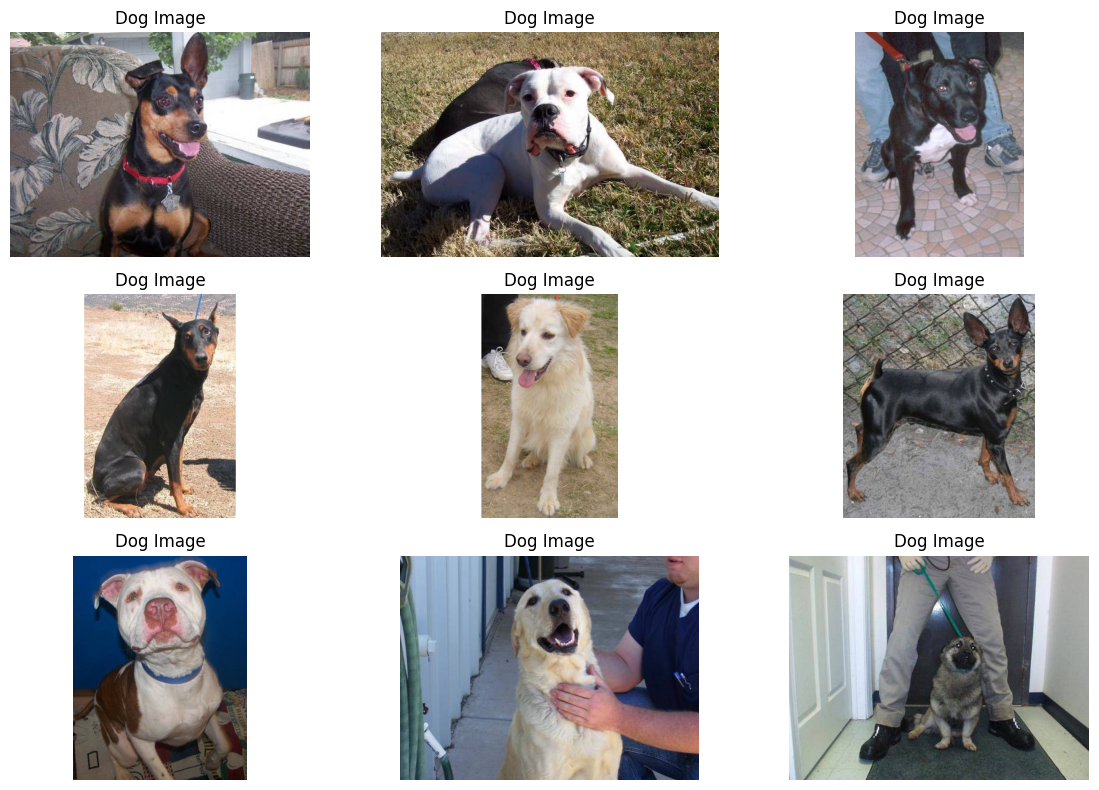

In [17]:
# =========================
# VISUALIZACIÓN DE IMÁGENES DE PERROS
# =========================

# Ruta principal
# del dataset organizado

data_dir = "../data/processed/train"

# Ruta de la carpeta
# de imágenes de perros

dog_subfolder = os.path.join(
    data_dir,
    "dog"
)

# Obtener nombres
# de archivos de perros

dog_image_files = os.listdir(
    dog_subfolder
)

# Lista para almacenar imágenes

dog_images = []

# Cargar las primeras
# 9 imágenes de perros

for i in range(9):

    # Ruta completa
    # de la imagen

    img_path = os.path.join(
        dog_subfolder,
        dog_image_files[i]
    )

    # Cargar imagen

    img = image.load_img(
        img_path
    )

    # Convertir imagen
    # a array numérico

    img_array = image.img_to_array(
        img
    )

    # Normalizar píxeles
    # entre 0 y 1

    img_array /= 255.0

    # Guardar imagen

    dog_images.append(
        img_array
    )

# =========================
# MOSTRAR IMÁGENES
# =========================

# Crear figura

plt.figure(
    figsize=(12, 8)
)

# Mostrar imágenes

for i in range(9):

    # Crear cuadrícula 3x3

    plt.subplot(
        3,
        3,
        i + 1
    )

    # Mostrar imagen

    plt.imshow(
        dog_images[i]
    )

    # Título

    plt.title(
        "Dog Image"
    )

    # Ocultar ejes

    plt.axis("off")

# Ajustar espacios

plt.tight_layout()

# Mostrar gráfico

plt.show()






Interpretación:

Se visualizan las primeras
imágenes de perros
del conjunto de entrenamiento.

Las imágenes presentan:
- distintos tamaños
- diferentes posiciones
- variaciones de iluminación
- diferentes fondos

Esto hace que el problema
de clasificación sea complejo
y requiera una CNN robusta.

Antes del entrenamiento,
las imágenes deberán:
- redimensionarse
- normalizarse
- procesarse correctamente
para entrar en la red neuronal.


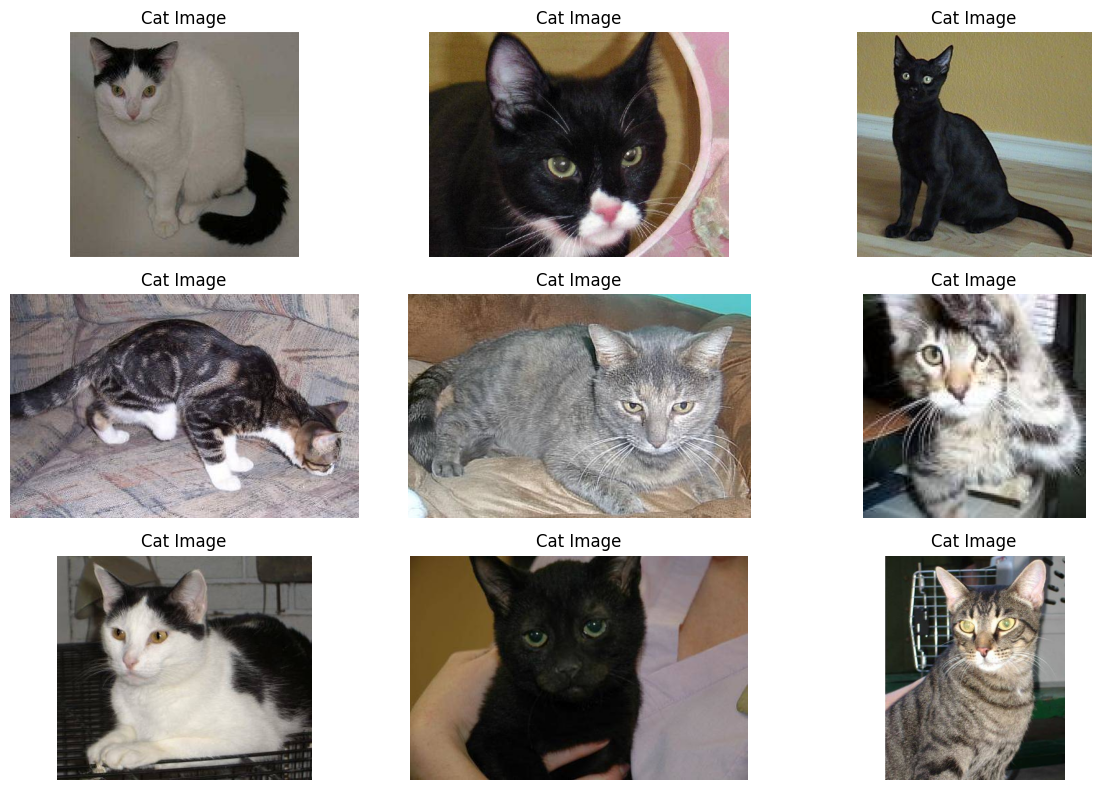

In [18]:
# =========================
# VISUALIZACIÓN DE IMÁGENES DE GATOS
# =========================

# Ruta principal
# del dataset organizado

data_dir = "../data/processed/train"

# Ruta de la carpeta
# de imágenes de gatos

cats_subfolder = os.path.join(
    data_dir,
    "cat"
)

# Obtener nombres
# de archivos de gatos

cats_image_files = os.listdir(
    cats_subfolder
)

# Lista para almacenar imágenes

cats_images = []

# Cargar las primeras
# 9 imágenes de gatos

# min(9, len(...)):
# evita errores si hubiera
# menos de 9 imágenes

for i in range(
    min(9, len(cats_image_files))
):

    # Ruta completa
    # de la imagen

    img_path = os.path.join(
        cats_subfolder,
        cats_image_files[i]
    )

    # Cargar imagen

    img = image.load_img(
        img_path
    )

    # Convertir imagen
    # a array numérico

    img_array = image.img_to_array(
        img
    )

    # Normalizar píxeles
    # entre 0 y 1

    img_array /= 255.0

    # Guardar imagen

    cats_images.append(
        img_array
    )

# =========================
# MOSTRAR IMÁGENES
# =========================

# Crear figura

plt.figure(
    figsize=(12, 8)
)

# Mostrar imágenes

for i in range(len(cats_images)):

    # Crear cuadrícula 3x3

    plt.subplot(
        3,
        3,
        i + 1
    )

    # Mostrar imagen

    plt.imshow(
        cats_images[i]
    )

    # Añadir título

    plt.title(
        "Cat Image"
    )

    # Ocultar ejes

    plt.axis("off")

# Ajustar espacios

plt.tight_layout()

# Mostrar gráfico final

plt.show()





Interpretación:

Se visualizan algunas imágenes
de gatos del conjunto
de entrenamiento.

Las imágenes presentan:
- distintos tamaños
- diferentes fondos
- variaciones de iluminación
- distintas posiciones del animal

Esta variabilidad aumenta
la dificultad del problema
de clasificación.

Por ello,
las imágenes deberán:
- redimensionarse
- normalizarse
- procesarse correctamente

antes de entrenar
la red neuronal convolucional.

In [1]:
# =========================
# GENERADORES DE IMÁGENES
# =========================

# Importamos ImageDataGenerator

# Esta clase permite:
# - cargar imágenes progresivamente
# - ahorrar memoria RAM
# - preparar imágenes para la CNN

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =========================
# DEFINIR RUTAS Y TAMAÑO
# =========================

# Ruta de entrenamiento

train_dir = "../data/processed/train"

# Ruta de prueba

test_dir = "../data/processed/test"

# Tamaño fijo de imágenes

# Todas las imágenes serán
# redimensionadas a 224x224

image_size = (224, 224)

# =========================
# CREAR GENERADORES
# =========================

# rescale=1./255:
# normaliza píxeles
# entre 0 y 1

datagentrain = ImageDataGenerator(
    rescale = 1./255
)

datagentest = ImageDataGenerator(
    rescale = 1./255
)

# =========================
# GENERADOR DE TRAIN
# =========================

train_data = datagentrain.flow_from_directory(

    train_dir,

    target_size = image_size,

    classes = ["dog", "cat"],

    batch_size = 32,

    class_mode = "categorical"

)

# =========================
# GENERADOR DE TEST
# =========================

test_data = datagentest.flow_from_directory(

    test_dir,

    target_size = image_size,

    classes = ["dog", "cat"],

    batch_size = 32,

    class_mode = "categorical"

)





I0000 00:00:1782320731.452015    5083 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782320731.514787    5083 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782320744.006164    5083 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.



Interpretación:

ImageDataGenerator permite cargar
las imágenes progresivamente
sin consumir demasiada memoria RAM.

Las imágenes:
- se redimensionan
- se normalizan
- se etiquetan automáticamente

El conjunto train
se utilizará para entrenar
la red neuronal.

El conjunto test
se utilizará para evaluar
el rendimiento del modelo.


In [9]:
# =========================
# CONSTRUCCIÓN DE UNA CNN MÁS LIGERA
# =========================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout

model = Sequential()

model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(224, 224, 3)
    )
)

model.add(MaxPool2D(2, 2))

model.add(
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    )
)

model.add(MaxPool2D(2, 2))

model.add(
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    )
)

model.add(MaxPool2D(2, 2))

model.add(Flatten())

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(
        2,
        activation="softmax"
    )
)




Interpretación:

Este modelo está inspirado
en la arquitectura VGG16.

Las capas convolucionales
extraen patrones visuales como:
- bordes
- formas
- texturas
- partes del animal

Las capas MaxPool2D reducen
la dimensión de la imagen
y conservan la información más importante.

Finalmente,
las capas densas utilizan
los patrones extraídos
para clasificar la imagen
como perro o gato.


In [10]:
# =========================
# COMPILACIÓN DEL MODELO
# =========================

# Importamos el optimizador Adam

# Adam:
# optimizador muy utilizado
# en redes neuronales profundas

# Combina:
# - descenso de gradiente
# - momentum
# - ajuste automático
# de learning rate

from tensorflow.keras.optimizers import Adam

# =========================
# COMPILAR EL MODELO
# =========================

# compile():
# prepara la red neuronal
# para comenzar el entrenamiento

model.compile(

    # Función de pérdida

    # categorical_crossentropy:
    # utilizada para problemas
    # de clasificación multiclase

    # En este caso:
    # perro o gato

     loss = "categorical_crossentropy",
    # Optimizador

    optimizer = Adam(
        learning_rate = 0.001
    ),

    # Métrica de evaluación

    # accuracy:
    # porcentaje de aciertos

    metrics = ["accuracy"]

)



In [11]:
# =========================
# ENTRENAMIENTO DEL MODELO
# =========================

hist = model.fit(
    train_data,
    steps_per_epoch = 20,
    epochs = 1,
    verbose = 1
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.4891 - loss: 0.9431


In [12]:
#Guardar el modelo:
# Importamos callbacks para controlar el entrenamiento
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Guarda automáticamente el mejor modelo
checkpoint = ModelCheckpoint(
    "../models/vgg16_1.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Detiene el entrenamiento si no mejora
early = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    verbose=1
)

# Entrenamos el modelo
hist = model.fit(
    train_data,
    steps_per_epoch=100,
    validation_data=test_data,
    validation_steps=10,
    epochs=3,
    callbacks=[checkpoint, early]
)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5318 - loss: 0.6950
Epoch 1: val_accuracy improved from None to 0.54688, saving model to ../models/vgg16_1.h5



Epoch 1: finished saving model to ../models/vgg16_1.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.5312 - loss: 0.6947 - val_accuracy: 0.5469 - val_loss: 0.6880
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5261 - loss: 0.6873
Epoch 2: val_accuracy did not improve from 0.54688
100/100 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.5587 - loss: 0.6841 - val_accuracy: 0.5344 - val_loss: 0.6795
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5814 - loss: 0.6749
Epoch 3: val_accuracy improved from 0.54688 to 0.64688, saving model to ../models/vgg16_1.h5



Epoch 3: finished saving model to ../models/vgg16_1.h5
100/100 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.5950 - loss: 0.6703 - val_accuracy: 0.6469 - val_loss: 0.6372


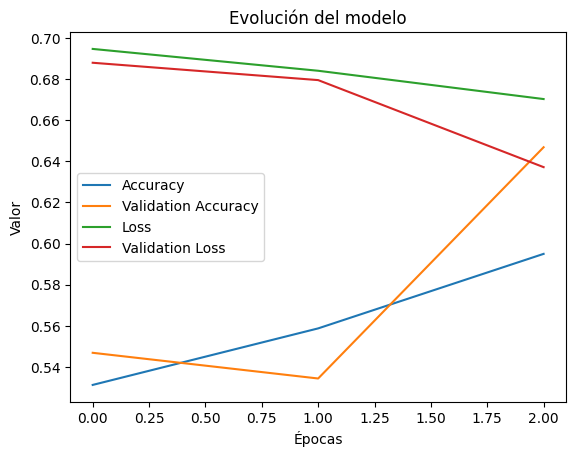

In [14]:
# Comprobamos la evolución del modelo durante el entrenamiento
import matplotlib.pyplot as plt

# Dibujamos la precisión (accuracy) en entrenamiento y validación
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])

# Dibujamos la pérdida (loss) en entrenamiento y validación
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])

# Configuración del gráfico
plt.title("Evolución del modelo")
plt.ylabel("Valor")
plt.xlabel("Épocas")

# Leyenda de las métricas representadas
plt.legend([
    "Accuracy",
    "Validation Accuracy",
    "Loss",
    "Validation Loss"
])

# Mostramos el gráfico
plt.show()

In [21]:
import os

jpg_files = []

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".jpg"):
            jpg_files.append(os.path.join(root, file))

print("Número de imágenes encontradas:", len(jpg_files))
print(jpg_files[:10])

Número de imágenes encontradas: 0
[]


In [22]:
import os

print(os.getcwd())
print(os.listdir("."))

/workspaces/image-classifier-project-tutorial
['README.es.md', 'preview.png', 'solution.es.ipynb', '2imagnes.ipynb', 'imagenes.ipynb', '.github', 'learn.json', 'README.md', '.git', 'solution.ipynb']


Imagen seleccionada: ../data/processed/test/cat/cat.538.jpg


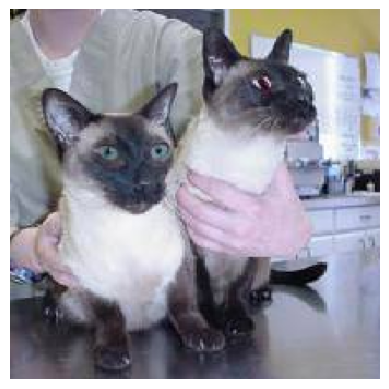

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step
[[1.0000000e+00 1.2440817e-18]]
cat


In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# =========================
# BUSCAR UNA IMAGEN DE TEST
# =========================

test_cat_dir = "../data/processed/test/cat"
test_dog_dir = "../data/processed/test/dog"

# Elegimos una imagen de gato
img_name = os.listdir(test_cat_dir)[0]

img_path = os.path.join(
    test_cat_dir,
    img_name
)

print("Imagen seleccionada:", img_path)

# =========================
# CARGAR IMAGEN
# =========================

img = image.load_img(
    img_path,
    target_size=(224, 224)
)

img_array = image.img_to_array(img)

plt.imshow(img_array / 255.0)
plt.axis("off")
plt.show()

# =========================
# PREPARAR IMAGEN PARA EL MODELO
# =========================

img_array = np.expand_dims(
    img_array,
    axis=0
)

# =========================
# CARGAR MODELO ENTRENADO
# =========================

saved_model = load_model(
    "../models/vgg16_1.h5"
)

# =========================
# PREDICCIÓN
# =========================

output = saved_model.predict(img_array)

print(output)

if output[0][0] > output[0][1]:
    print("cat")
else:
    print("dog")